### Sign Language Detection with MediaPipe & TFLite
Run the cells below to mount your drive, load your models, and process an image. **Remember to update the file paths in the second code cell before running.**

In [ ]:
# Install mediapipe and mount Google Drive
!pip install mediapipe -q

from google.colab import drive
drive.mount('/content/drive')

In [4]:
import os
import json
import numpy as np
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import tensorflow as tf
from google.colab.patches import cv2_imshow
from google.colab import files


TFLITE_MODEL_PATH = "/content/drive/MyDrive/ML-CEP/test/handsign_cnn.tflite"
CLASS_INDICES_PATH = "/content/drive/MyDrive/ML-CEP/test/class_indices.json"
HAND_TASK_MODEL = "/content/drive/MyDrive/ML-CEP/test/hand_landmarker.task"

IMG_SIZE = 128
PADDING_RATIO = 0.2


In [5]:

print("Loading TFLite model...")
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Loading class indices...")
with open(CLASS_INDICES_PATH, "r") as f:
    class_indices = json.load(f)
idx_to_class = {v: k for k, v in class_indices.items()}
CLASS_NAMES = [idx_to_class[i] for i in range(len(idx_to_class))]

print("Loading MediaPipe Hand Landmarker...")
BaseOptions = python.BaseOptions
HandLandmarker = vision.HandLandmarker
HandLandmarkerOptions = vision.HandLandmarkerOptions
VisionRunningMode = vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=HAND_TASK_MODEL),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=1
)
landmarker = HandLandmarker.create_from_options(options)



Loading TFLite model...
Loading class indices...
Loading MediaPipe Hand Landmarker...


In [6]:
def predict(crop_bgr):
    img = cv2.resize(crop_bgr, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)

    if input_details[0]["dtype"] == np.uint8:
        scale, zero_point = input_details[0]["quantization"]
        img = (img / scale + zero_point).astype(np.uint8)

    interpreter.set_tensor(input_details[0]["index"], img)
    interpreter.invoke()
    probs = interpreter.get_tensor(output_details[0]["index"])[0]

    if output_details[0]["dtype"] == np.uint8:
        out_scale, out_zp = output_details[0]["quantization"]
        probs = (probs.astype(np.float32) - out_zp) * out_scale

    idx = int(np.argmax(probs))
    return CLASS_NAMES[idx], float(probs[idx])

def get_hand_crop(image_bgr):
    h, w = image_bgr.shape[:2]
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect(mp_image)

    if not result.hand_landmarks:
        return None, None

    hand = result.hand_landmarks[0]
    xs = [lm.x * w for lm in hand]
    ys = [lm.y * h for lm in hand]
    x1, x2 = min(xs), max(xs)
    y1, y2 = min(ys), max(ys)

    pad_x = (x2 - x1) * PADDING_RATIO
    pad_y = (y2 - y1) * PADDING_RATIO
    x1 = int(max(0, x1 - pad_x))
    y1 = int(max(0, y1 - pad_y))
    x2 = int(min(w,  x2 + pad_x))
    y2 = int(min(h,  y2 + pad_y))

    crop = image_bgr[y1:y2, x1:x2]
    return crop, (x1, y1, x2, y2)

def draw_prediction(img, box, label, confidence):
    FONT = cv2.FONT_HERSHEY_SIMPLEX
    BOX_COLOR = (0, 180, 255)
    TEXT_COLOR = (255, 255, 255)
    x1, y1, x2, y2 = box
    cv2.rectangle(img, (x1, y1), (x2, y2), BOX_COLOR, 2)
    text = f"{label} {confidence*100:.1f}%"
    (tw, th), baseline = cv2.getTextSize(text, FONT, 1.0, 2)
    bg_y1 = max(0, y1 - th - baseline - 8)
    cv2.rectangle(img, (x1, bg_y1), (x1 + tw + 8, y1), BOX_COLOR, -1)
    cv2.putText(img, text, (x1 + 4, y1 - baseline - 2), FONT, 1.0, TEXT_COLOR, 2, cv2.LINE_AA)


Please upload an image for hand sign detection:


Saving img_0.jpg to img_0.jpg
Prediction: B (93.21%)


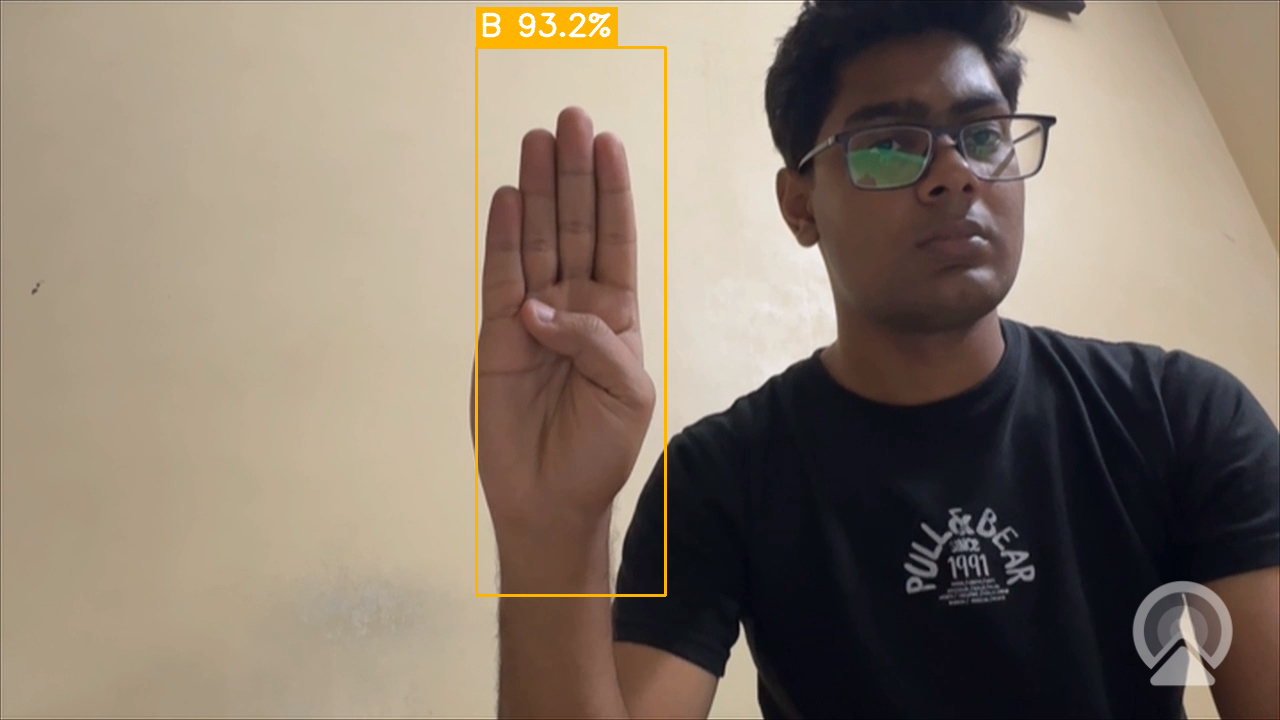

In [7]:
print("Please upload an image for hand sign detection:")
uploaded = files.upload()

if not uploaded:
    print("Error: No image was uploaded.")
else:
    # Get the filename of the uploaded image
    test_image_path = list(uploaded.keys())[0]

    img = cv2.imread(test_image_path)
    if img is None:
        print("Error: Could not read image.")
    else:
        output_img = img.copy()
        crop, box = get_hand_crop(img)

        if crop is None or crop.size == 0:
            cv2.putText(output_img, "No hand detected", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3, cv2.LINE_AA)
            print("No hand detected.")
        else:
            label, confidence = predict(crop)
            draw_prediction(output_img, box, label, confidence)
            print(f"Prediction: {label} ({confidence*100:.2f}%)")

        # Display the result inline
        cv2_imshow(output_img)